# Yeast Protein Localization Prediction using Random Forest

### Applied Machine Learning Project

**Author:** Mustafa Barkın Kemeç  
**Program:** MSc Bioinformatics  
**University:** Alma Mater Studiorum – Università di Bologna  

---

## Project Overview

The aim of this project is to build and evaluate machine learning models capable of predicting the cellular localization site of yeast proteins using 8 numerical biological features.

Protein localization is an important problem in bioinformatics because the cellular location of a protein is strongly related to its biological function. Experimental determination of localization can be expensive and time-consuming, therefore computational prediction methods are highly valuable.

This project uses the Yeast Protein Localization dataset from the UCI Machine Learning Repository. The dataset contains 1484 protein samples represented by biologically meaningful numerical features related to signal peptides, membrane regions, mitochondrial targeting, nuclear localization, and other cellular targeting mechanisms.

The project follows a complete machine learning workflow including:

- exploratory data analysis,
- feature selection,
- resampling techniques,
- model evaluation,
- algorithm comparison,
- hyperparameter tuning,
- and final benchmark evaluation.

Special attention is given to class imbalance and prevention of data leakage during model development.

## Data Splitting and Fold Management

Before model development, a custom data splitting procedure was applied using a separate Python script (Inside the /src folder):

- `split_data.py`

The original dataset was divided into:

- approximately **75% training data**
- approximately **25% benchmark test data**

The benchmark samples were labeled with:

- `fold = -1`

The remaining training portion was further divided into three folds:

- `fold = 0`
- `fold = 1`
- `fold = 2`

This custom fold structure was created to support cross-validation while keeping a completely unseen benchmark set for final evaluation.

A class-aware splitting strategy was used because the dataset is relatively small and highly imbalanced. This ensured that every localization class — including rare classes such as ERL and POX — was represented in all folds and in the benchmark set.

This approach helps:

- prevent data leakage,
- improve fairness of evaluation,
- and avoid excluding minority classes during training or testing.

The following files were generated during the splitting process:

- `yeast_folds.tsv` → full dataset including fold assignments
- `fold_index.tsv` → lightweight/shareable file containing only `seq_name` and `fold`

## Exploratory Data Analysis

In [1]:
import pandas as pd

filename="data/yeast_folds.tsv"

data = pd.read_csv(filename, sep=r"\s+")  # "\s+" for .tsv file

print(type(data))  # for checking the df type

data.head()  # To visualize first 5 line

<class 'pandas.DataFrame'>


,seq_name,mcg,gvh,alm,mit,erl,pox,vac,nuc,class,fold
0,TNT_YEAST,0.59,0.60,0.49,0.43,0.5,0.0,0.53,0.31,MIT,-1
1,HS60_YEAST,0.45,0.56,0.51,0.64,0.5,0.0,0.54,0.22,MIT,0
2,RSD1_YEAST,0.57,0.50,0.40,0.08,0.5,0.0,0.47,0.22,ME3,-1
3,LOS1_YEAST,0.53,0.44,0.47,0.22,0.5,0.0,0.53,0.22,NUC,-1
4,YEP0_YEAST,0.38,0.37,0.36,0.14,0.5,0.0,0.54,0.22,ME3,0


In [2]:
data.tail() # To visualize last 5 line

,seq_name,mcg,gvh,alm,mit,erl,pox,vac,nuc,class,fold
1479,SNQ2_YEAST,0.45,0.57,0.38,0.28,0.5,0.0,0.53,0.31,ME3,1
1480,TRPD_YEAST,0.45,0.76,0.51,0.25,0.5,0.0,0.59,0.22,CYT,0
1481,PUT2_YEAST,0.45,0.53,0.51,0.42,0.5,0.0,0.52,0.22,MIT,2
1482,YKM9_YEAST,0.41,0.45,0.46,0.23,0.5,0.0,0.50,0.70,CYT,1
1483,SNF6_YEAST,0.55,0.40,0.62,0.22,0.5,0.0,0.37,0.28,NUC,-1


In [3]:
print(data.shape) # check the row and column numbers, it helps confirm dataset size

(1484, 11)


In [4]:
print(data.dtypes) # To see the data types and check if features are numeric and usable for ML models

seq_name        str
mcg         float64
gvh         float64
alm         float64
mit         float64
erl         float64
pox         float64
vac         float64
nuc         float64
class           str
fold          int64
dtype: object


In [5]:
from pandas import set_option  # for display settings

set_option("display.width", 200) 
set_option("display.max_rows", 500)
set_option("display.max_columns", 500)  

description = data.describe() # We can see some statistics about data and features
print(description)

               mcg          gvh          alm          mit          erl          pox          vac          nuc         fold
count  1484.000000  1484.000000  1484.000000  1484.000000  1484.000000  1484.000000  1484.000000  1484.000000  1484.000000
mean      0.500121     0.499933     0.500034     0.261186     0.504717     0.007500     0.499885     0.276199     0.492588
std       0.137299     0.123924     0.086670     0.137098     0.048351     0.075683     0.057797     0.106491     1.117783
min       0.110000     0.130000     0.210000     0.000000     0.500000     0.000000     0.000000     0.000000    -1.000000
25%       0.410000     0.420000     0.460000     0.170000     0.500000     0.000000     0.480000     0.220000    -1.000000
50%       0.490000     0.490000     0.510000     0.220000     0.500000     0.000000     0.510000     0.220000     0.000000
75%       0.580000     0.570000     0.550000     0.320000     0.500000     0.000000     0.530000     0.300000     1.000000
max       1.0000

### Dataset Summary

With the `describe()` function, we observe:

- The dataset contains **1484 complete observations** with no missing values.
- All features are **continuous numerical values** scaled between **0 and 1** (already normalized).
- The `fold` column is **not a biological feature**; it is an artificial split indicator used for validation and benchmark separation.

In [6]:
print(data["class"].unique())  # list of class labels

<StringArray>
['MIT', 'ME3', 'NUC', 'CYT', 'ME2', 'POX', 'VAC', 'ME1', 'EXC', 'ERL']
Length: 10, dtype: str


In [7]:
class_counts = data.groupby("class").size()  # the sample number of each class
print(class_counts)

class
CYT    463
ERL      5
EXC     35
ME1     44
ME2     51
ME3    163
MIT    244
NUC    429
POX     20
VAC     30
dtype: int64


### Class Distribution Observation

- The dataset is clearly imbalanced.
- CYT and NUC dominate the dataset, while classes like ERL have very few samples.
- This imbalance will be considered during model training and evaluation.

In [8]:
numeric_cols = ["mcg","gvh","alm","mit","erl","pox","vac","nuc"]  # numeric columns

correlations = data[numeric_cols].corr(method="pearson")  # Pearson correlations matrix
correlations

,mcg,gvh,alm,mit,erl,pox,vac,nuc
mcg,1.000000,0.581631,-0.163951,0.158175,0.064922,0.005597,0.075043,-0.124540
gvh,0.581631,1.000000,-0.271800,0.140314,0.060823,0.000392,0.088759,-0.102984
alm,-0.163951,-0.271800,1.000000,0.059668,-0.008083,0.009378,-0.185805,-0.022043
mit,0.158175,0.140314,0.059668,1.000000,-0.005931,-0.009040,-0.103591,-0.054797
erl,0.064922,0.060823,-0.008083,-0.005931,1.000000,-0.009674,0.043627,0.002829
pox,0.005597,0.000392,0.009378,-0.009040,-0.009674,1.000000,0.020900,-0.035659
vac,0.075043,0.088759,-0.185805,-0.103591,0.043627,0.020900,1.000000,0.089690
nuc,-0.124540,-0.102984,-0.022043,-0.054797,0.002829,-0.035659,0.089690,1.000000


- Most features show low correlations, so they are approximately independent.
- The strongest correlation is between `mcg` and `gvh` (≈ 0.58).

In [9]:
skew = data[numeric_cols].skew()  # to see skewed value for each numeric column
print(skew)

mcg     0.604291
gvh     0.416639
alm    -0.220995
mit     1.444776
erl    10.159633
pox    10.276884
vac    -1.791641
nuc     2.413031
dtype: float64


### Skewness Interpretation

Skewness measures the asymmetry of the distribution of data:

- `skew = 0` → roughly symmetric (similar to a normal distribution)
- `skew > 0` → positively skewed (right tail is longer)
- `skew < 0` → negatively skewed (left tail is longer)

### Feature Interpretation

- `mit`, `nuc`, `erl`, and `pox` show strong positive skewness.
- Especially `erl` and `pox` have extremely high skew values (~10), suggesting that these signals are rare and activated only in a small subset of proteins.
- This is biologically plausible, since some localization signals (e.g., ER retention or peroxisomal targeting) are expected to appear only in specific protein groups.
- `vac` shows strong negative skewness, meaning most proteins have relatively high scores, with fewer proteins having very low values.
- `mcg` and `gvh` are closer to symmetric, indicating more evenly distributed signal recognition scores.

### Model Interpretation

- Since the dataset is imbalanced and some features represent rare biological signals, skewness may reflect biologically meaningful sparsity rather than noise.
- Tree-based models are generally robust to skewed distributions because they rely on threshold-based splits rather than distances.
- Distance-based models may be more sensitive to extreme asymmetry.

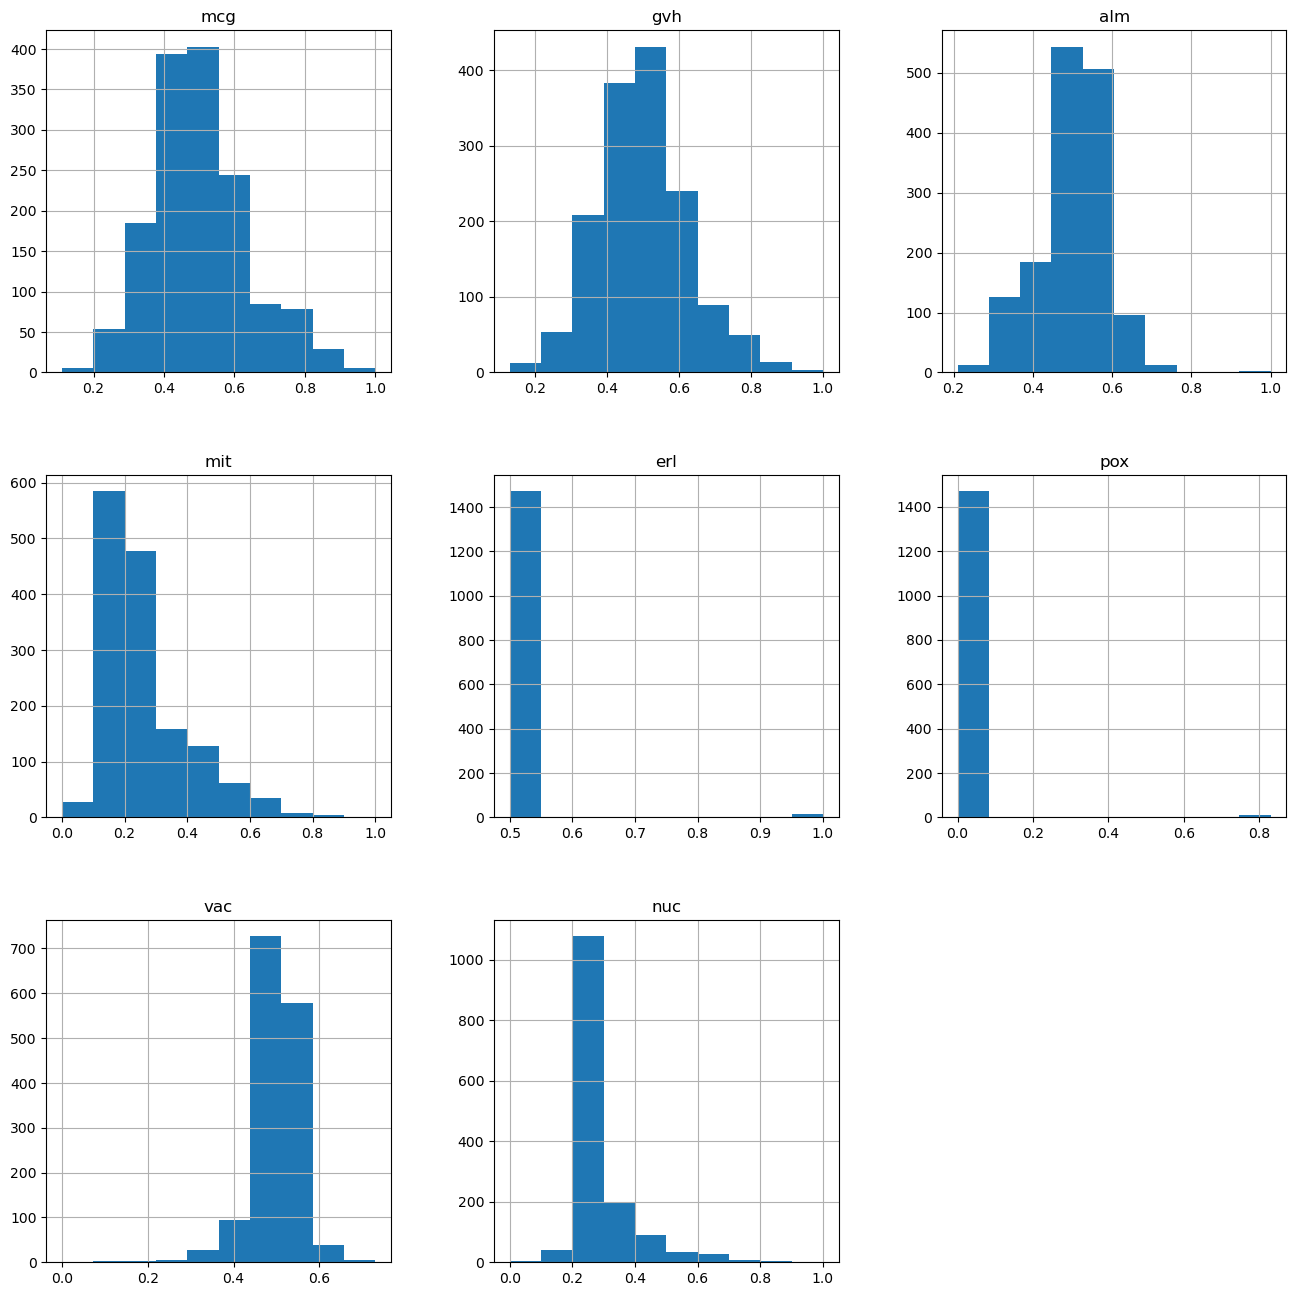

In [39]:
from matplotlib import pyplot

pyplot.rcParams["figure.figsize"] = [16, 16]  # to visualize better
data[numeric_cols].hist()  # with this line of code, we can create a histogram plot for every numerical features
plt.savefig("figures/histogram_graph.png", dpi=300, bbox_inches="tight")
pyplot.show()  # to show the graphs

### Histogram Analysis

- `mcg`, `gvh`, and `alm` are relatively concentrated around the middle range, mostly between `0.3` and `0.7`.
- Among them, `mcg` and `gvh` show a slightly right-skewed pattern, while `alm` is more centered and slightly left-skewed.

- `mit` is clearly right-skewed, with most proteins having low-to-moderate mitochondrial signal scores and fewer proteins showing high values.

- `erl` and `pox` are highly sparse. Most samples have the same low/default value, while only a very small number of proteins show high values.
- This supports the idea that ER retention and peroxisomal targeting signals are rare in this dataset.

- `vac` is concentrated around relatively high values, especially near `0.5`, with a longer tail toward lower values.
- This explains its negative skewness.

- `nuc` is also right-skewed, with most values concentrated around `0.2–0.3` and fewer proteins having high nuclear localization scores.

- Overall, the histograms confirm that the features are normalized between `0` and `1`, but their distributions are not uniform.
- Some features represent broadly distributed signals, while others capture rare biological signals.

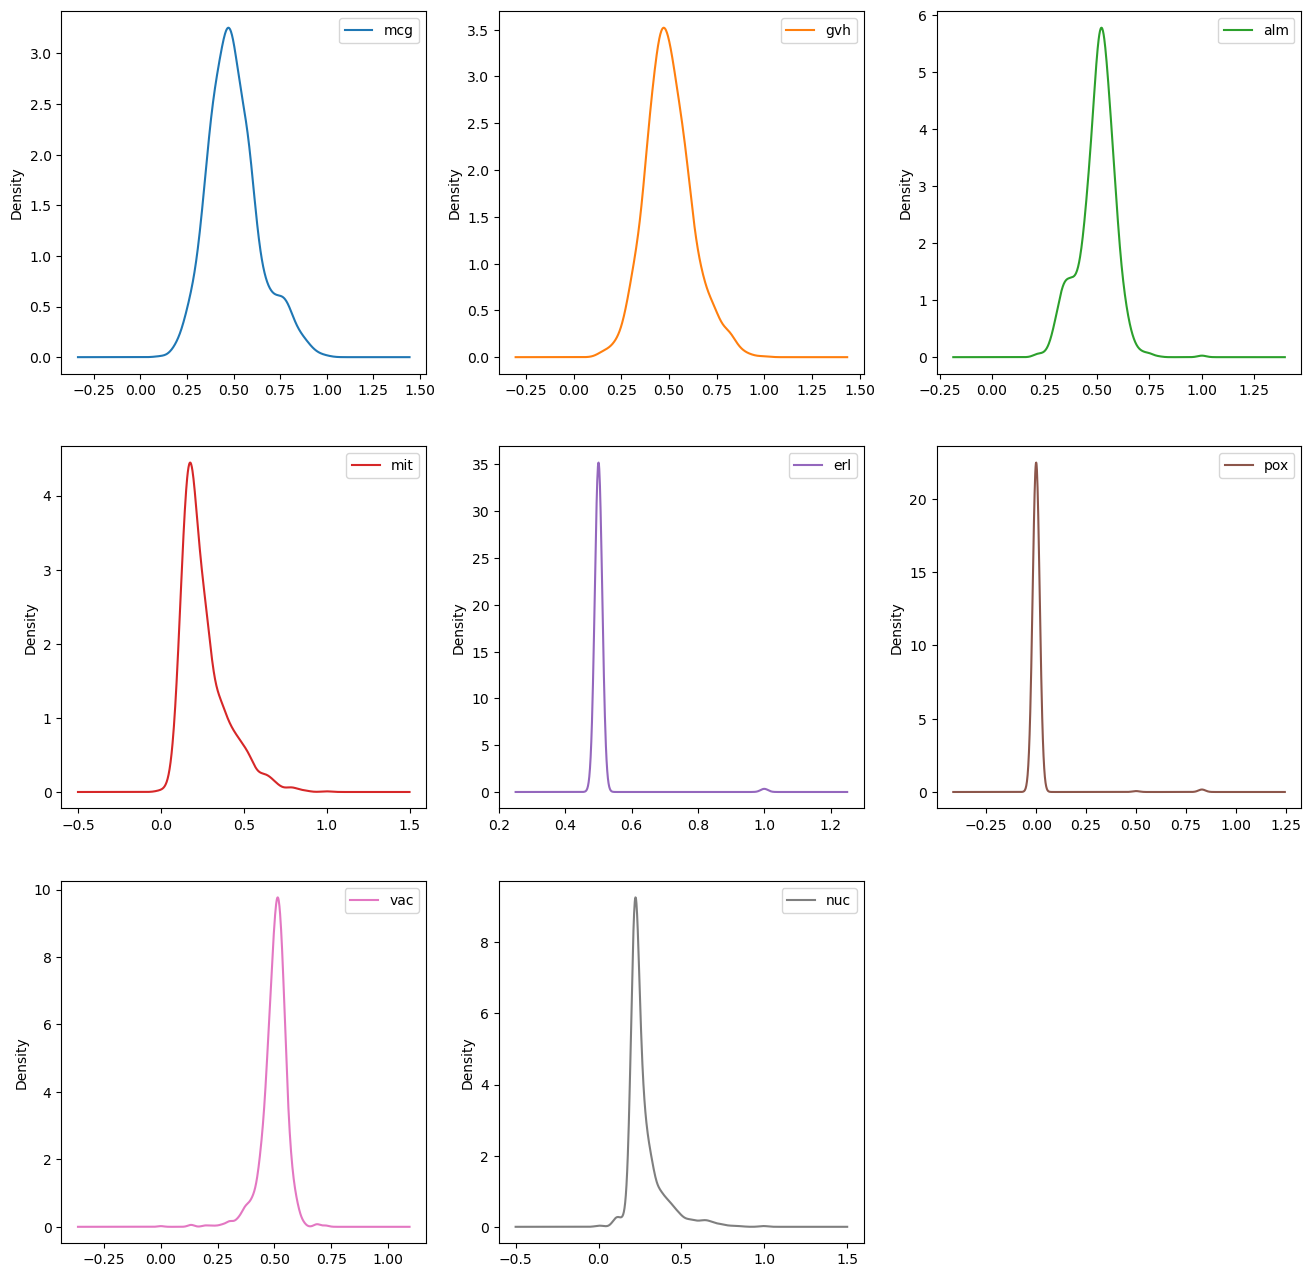

In [40]:
data[numeric_cols].plot(kind="density", subplots=True, layout=(3,3), sharex=False)  # density plot for every feature for visualize shape easily
plt.savefig("figures/density_plot.png", dpi=300, bbox_inches="tight")
pyplot.show()

### Density Plot Analysis

- `mcg`, `gvh`, and `alm` show approximately bell-shaped distributions centered around mid-range values, indicating that these signals are relatively equally distributed across proteins.

- `mit` is clearly right-skewed, with a strong peak at low values and a long tail toward higher values.
- This suggests that most proteins have low mitochondrial targeting scores, while fewer proteins show strong signals.

- `erl` shows an extremely sharp peak around `~0.5`, indicating that most samples share nearly identical values.
- A very small secondary bump near higher values suggests rare activation of this signal.

- `pox` has a sharp peak near zero, with a long right tail.
- This confirms that most proteins lack this signal, while only a few exhibit strong peroxisomal targeting signals.

- `vac` is highly concentrated around `~0.5` with a slight tail toward lower values.

- `nuc` shows a strong peak at low-to-mid values with a long right tail, indicating that high nuclear localization scores are less frequent.

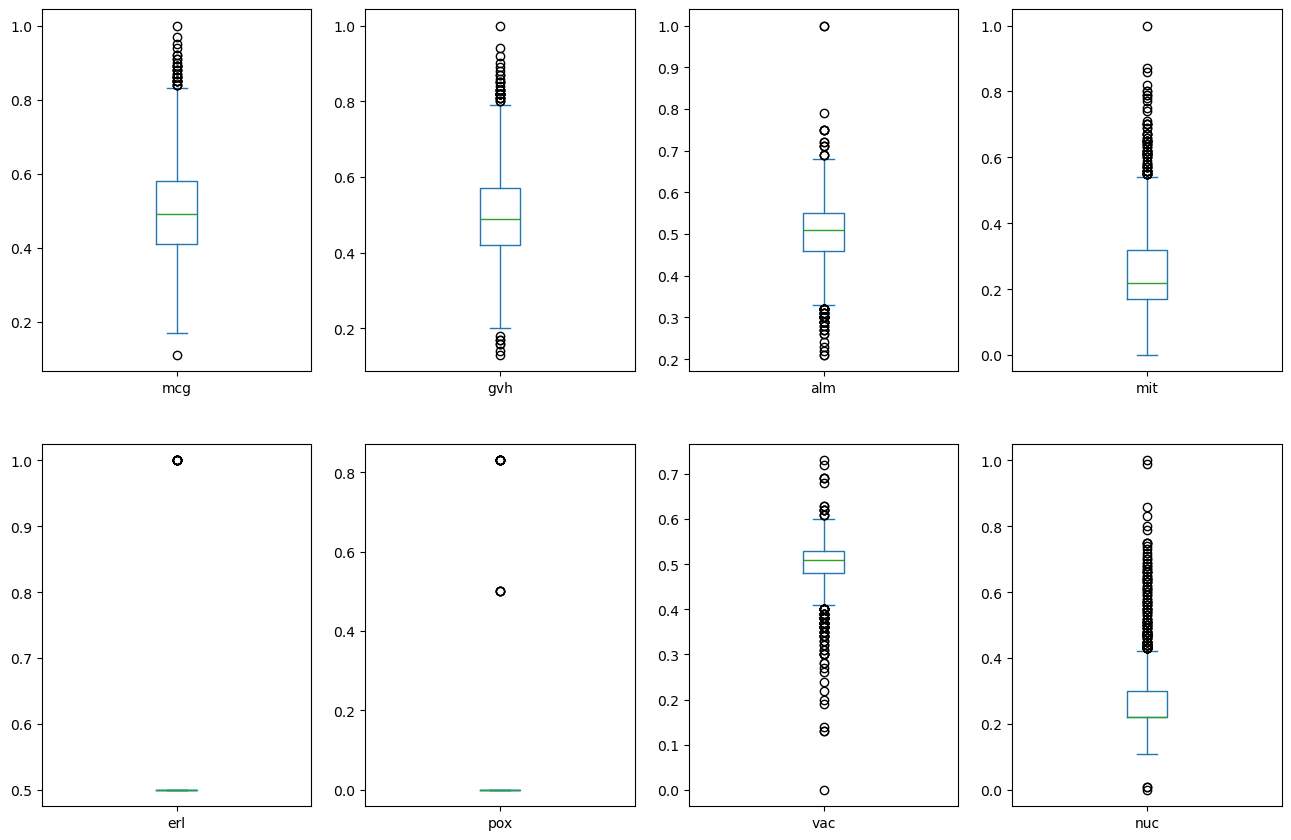

In [41]:
data[numeric_cols].plot(kind="box", subplots=True, layout=(3,4), sharex=False, sharey=False)  # boxplot for every feature
plt.savefig("figures/box_plot.png", dpi=300, bbox_inches="tight")
pyplot.show()

### Boxplot Analysis

- `mcg`, `gvh`, and `alm` show relatively symmetric distributions with moderate spread.
- However, several upper (`mcg`, `gvh`) and lower (`alm`) outliers are present, indicating proteins with unusually high and low signal scores.

- `mit` is clearly right-skewed, with the median located toward lower values and many outliers extending toward higher values.
- This confirms that strong mitochondrial signals are less common.

- `erl` has almost no variability: the box is extremely compressed around `~0.5`, with only a few extreme outliers near `1.0`.
- This indicates that most proteins share nearly identical values, with rare deviations.

- `pox` shows a similar pattern: most values are concentrated at the lower end (near `0`), with a few high-value outliers.

- `vac` is tightly centered around `~0.5` but shows more spread compared to `erl`.
- It also contains both lower and upper outliers, with more variation toward lower values, consistent with negative skewness.

- `nuc` shows a strong right-skewed distribution, with many upper outliers.
- This indicates that while most proteins have moderate nuclear localization scores, some have significantly higher values.

- Overall, boxplots confirm that many features contain outliers, which are likely biologically meaningful rather than noise.
- Features with many outliers may contain important biological signals useful for classification.

In [13]:
correlations = data[numeric_cols].corr()  # correlation matrix for features
correlations

,mcg,gvh,alm,mit,erl,pox,vac,nuc
mcg,1.000000,0.581631,-0.163951,0.158175,0.064922,0.005597,0.075043,-0.124540
gvh,0.581631,1.000000,-0.271800,0.140314,0.060823,0.000392,0.088759,-0.102984
alm,-0.163951,-0.271800,1.000000,0.059668,-0.008083,0.009378,-0.185805,-0.022043
mit,0.158175,0.140314,0.059668,1.000000,-0.005931,-0.009040,-0.103591,-0.054797
erl,0.064922,0.060823,-0.008083,-0.005931,1.000000,-0.009674,0.043627,0.002829
pox,0.005597,0.000392,0.009378,-0.009040,-0.009674,1.000000,0.020900,-0.035659
vac,0.075043,0.088759,-0.185805,-0.103591,0.043627,0.020900,1.000000,0.089690
nuc,-0.124540,-0.102984,-0.022043,-0.054797,0.002829,-0.035659,0.089690,1.000000


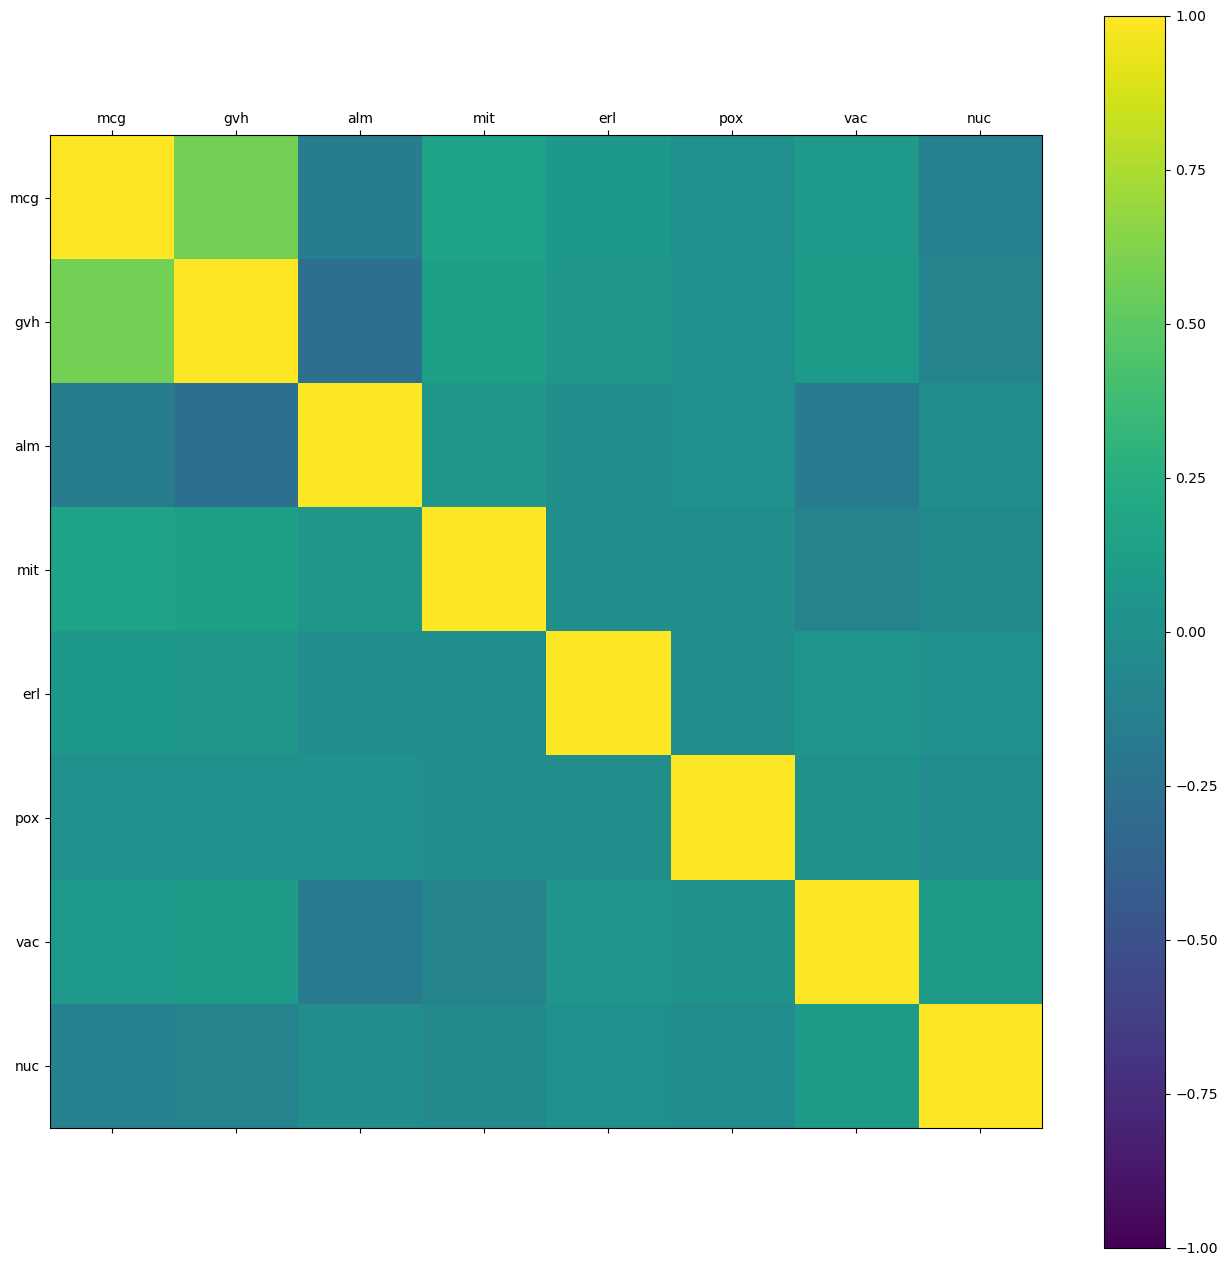

In [14]:
import numpy
# correlation heatmap
fig = pyplot.figure()  # to create new figure
ax = fig.add_subplot(111)  # for one subplot
cax = ax.matshow(correlations, vmin=-1, vmax=1)  # heatmap for visualize the correlations better
fig.colorbar(cax) # colorbar

ticks = numpy.arange(0, len(numeric_cols), 1)  # tick indexes
ax.set_xticks(ticks)
ax.set_yticks(ticks) 
ax.set_xticklabels(numeric_cols)  # feature names for x-axis
ax.set_yticklabels(numeric_cols)  # feature names for y-axis

pyplot.show()

### Correlation Analysis

- The correlation matrix shows the linear relationships between numerical features.

- Most feature pairs have very low correlation values, indicating that the features are largely independent.

- The only important correlation is between `mcg` and `gvh` (`~0.58`), which suggests a moderate positive relationship.
- This is expected, as both features are related to signal sequence recognition.

- Overall, there is no strong multicollinearity in the dataset.

### Model Interpretation

- Since features are mostly independent, using all features together is not expected to cause major redundancy problems.
- Low correlations also suggest that each feature may contribute unique information to the classification task.
- The model is therefore expected to benefit from combining multiple features rather than relying on a single dominant predictor.

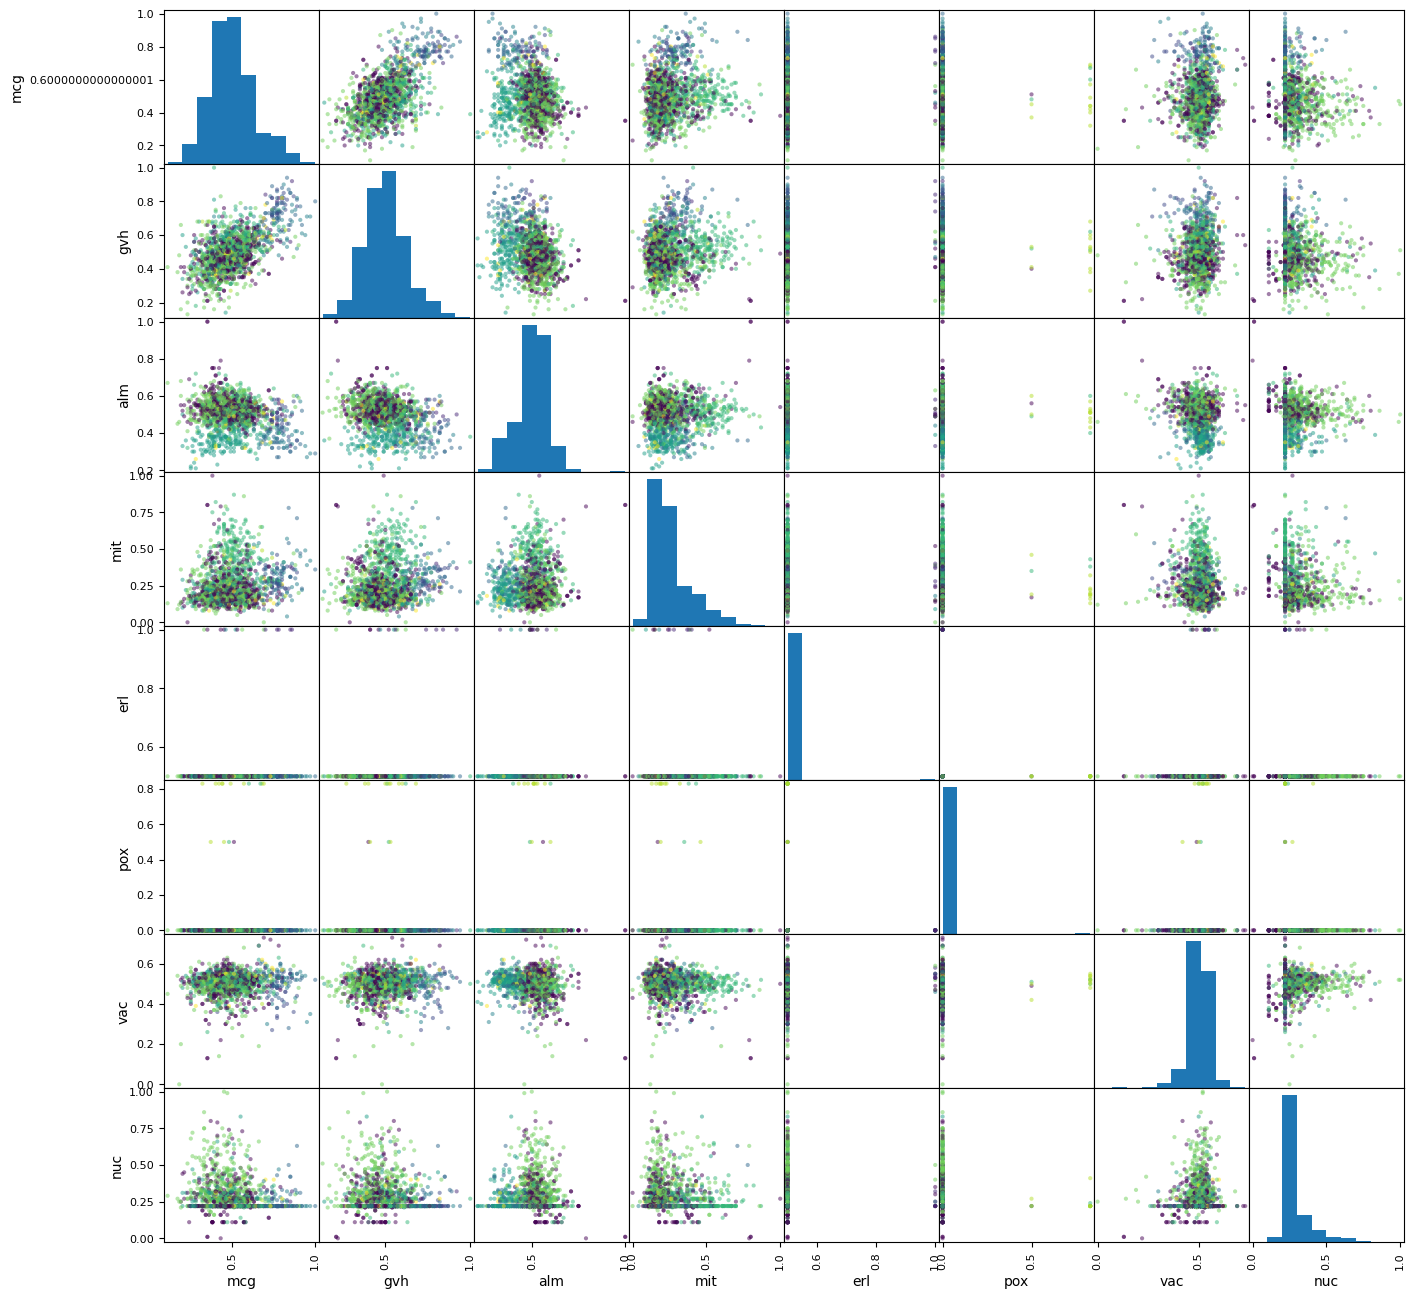

In [42]:
from pandas.plotting import scatter_matrix
classes = data["class"].astype("category")
colors = classes.cat.codes
scatter_matrix(data[numeric_cols], c=colors)
plt.savefig("figures/scatter_plot.png", dpi=300, bbox_inches="tight")
pyplot.show()

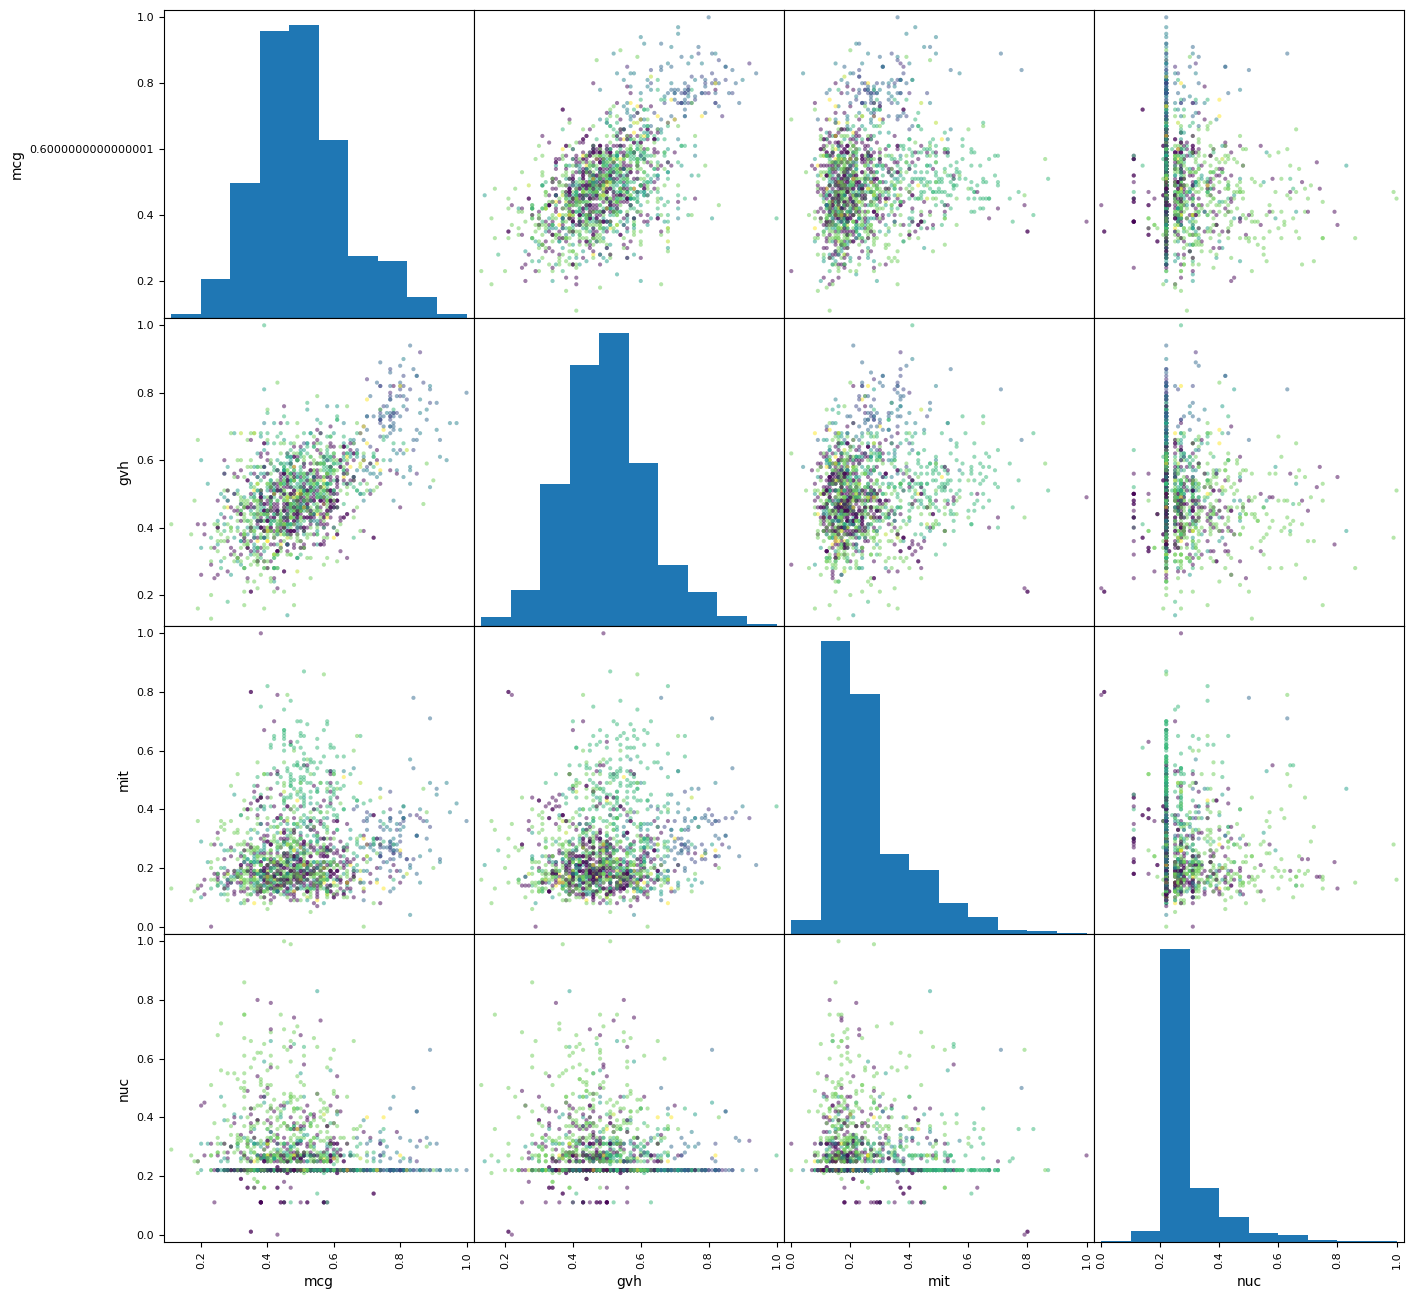

In [16]:
selected_cols = ["mcg","gvh","mit","nuc"]  # select less feature to better visualize
scatter_matrix(data[selected_cols], c=colors)  # scatter matrix with selected features
pyplot.show() 

### Scatter Matrix Analysis 
- The scatter matrix visualizes the pairwise relationships between all numerical features. 
- Most feature pairs do not show clear linear relationships, consistent with the previously observed low correlation values. 
- The only trend occurs between mcg and gvh, where a moderately positive relationship can be observed. This is consistent with correlation analysis. 
- No clear separation appears between data points in any feature pair.
- The absence of apparent separation indicates that the dataset is not linearly separable. 
- This suggests that simple linear models may be insufficient, but nonlinear models are more appropriate.

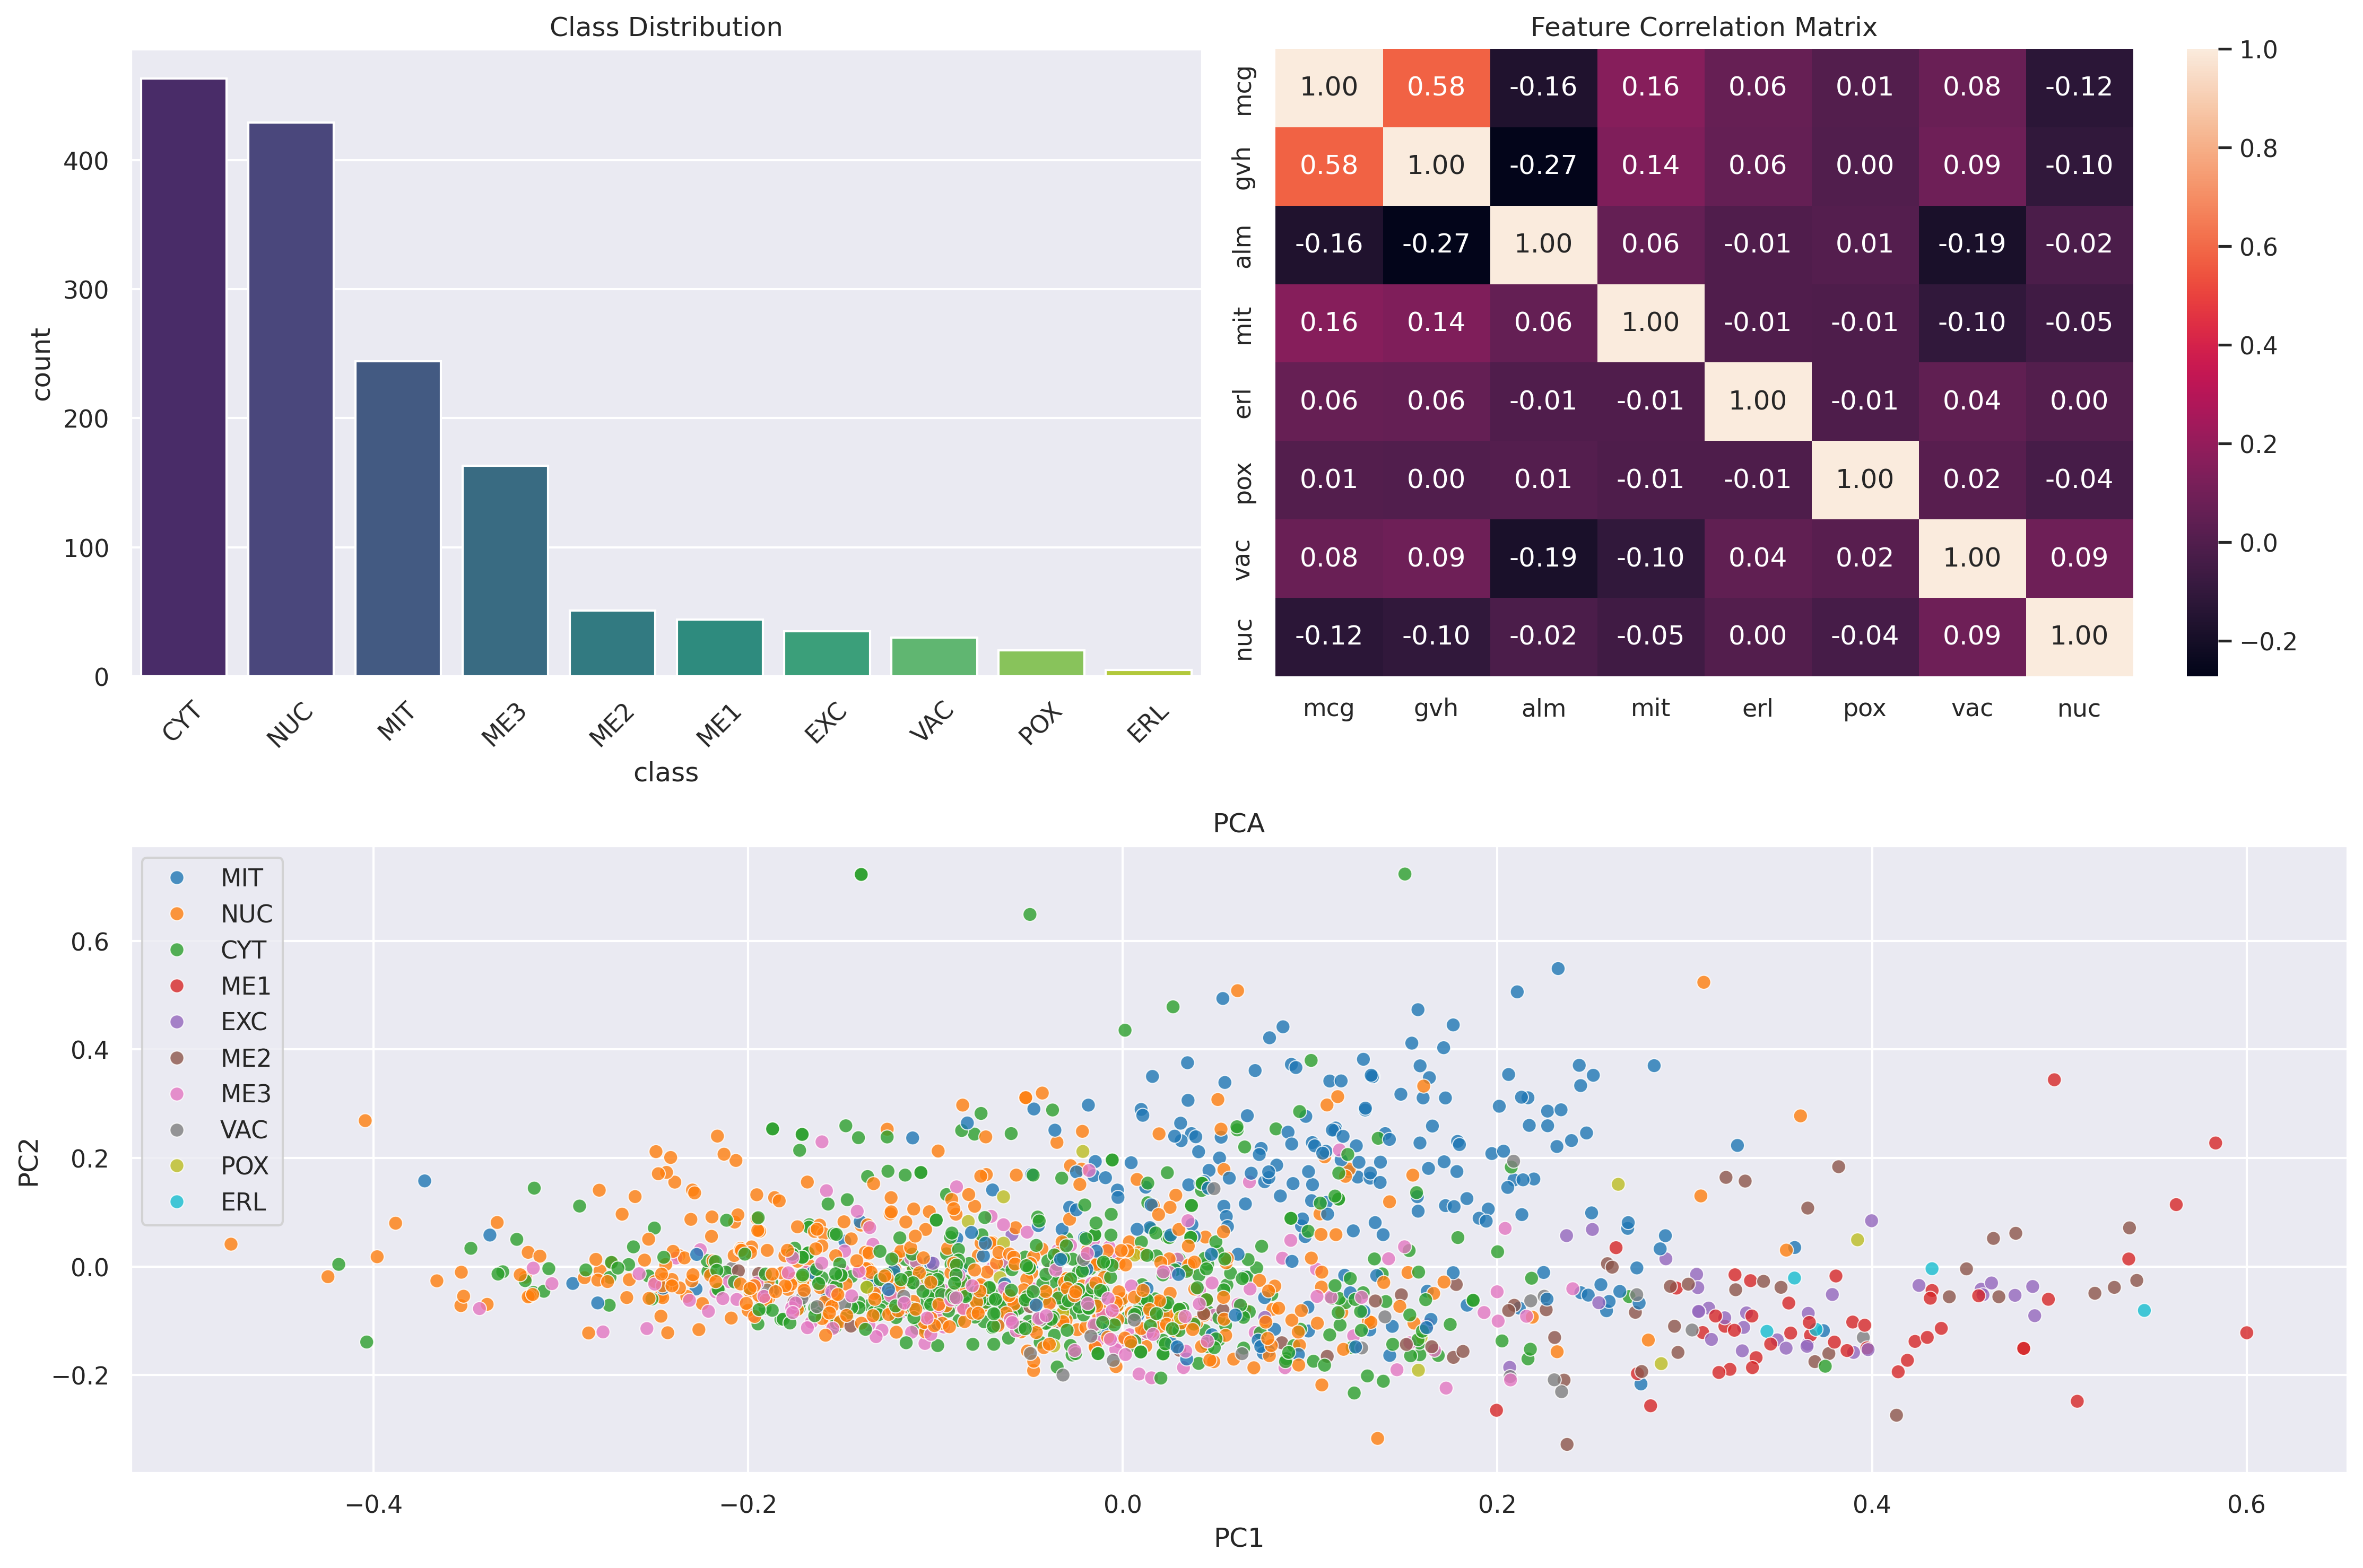

In [17]:
from IPython.display import Image

Image(filename="data_explore_overview.png")

### Combined Data Overview (Class Distribution, Correlation, PCA)

- This figure summarizes the key aspects of the dataset: class distribution, feature relationships, and dimensionality reduction.

- The class distribution confirms a strong imbalance, with `CYT` and `NUC` being dominant, and classes like `ERL` and `POX` having very few examples.

- Key observations from PCA:

- Clear clustering boundaries between classes are not apparent.

- Some slight clustering tendencies exist (partial spread of certain classes like `ME1`), but the separation is not strong.

- Most classes are distributed across similar regions of the feature space.

- PCA shows that class information is not captured by simple linear models.
- The dataset is not linearly separable.

- ! Classification will require models capable of capturing nonlinear relationships.

- Class imbalance may complicate learning, especially for rare classes.

## Feature Selection

Feature selection aims to identify the most informative variables for the classification task.

In this project, multiple feature selection approaches are explored:

- Univariate Selection using Chi-square
- Recursive Feature Elimination
- Tree-based Feature Importance

However, due to the characteristics of the yeast dataset, not all methods are equally suitable. The dataset is small, highly imbalanced, and contains a multi-class target with 10 localization classes. Therefore, tree-based feature importance is used as the main feature selection approach.

In [18]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, chi2, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from numpy import set_printoptions


### Data Leakage Prevention

The dataset includes a predefined benchmark fold labeled as `-1`.

This fold must not be used during feature selection or model development, because it is reserved for the final benchmark evaluation.

So, only folds `0`, `1`, and `2` are used in the following feature selection steps.

In [19]:
feature_names = ["mcg","gvh","alm","mit","erl","pox","vac","nuc"]

# Benchmark fold is excluded to prevent data leakage
train_data = data[data["fold"] != -1]

X = train_data[feature_names].values
Y_raw = train_data["class"].values

le = LabelEncoder()
Y = le.fit_transform(Y_raw)

print(X.shape)
print(Y.shape)

(1110, 8)
(1110,)


### 1. Univariate Selection with Chi-square

Chi-square feature selection was applied as a baseline method.

This method can be used here because all Yeast features are non-negative and scaled between 0 and 1.

However, chi-square is not used as the main feature selection method because the dataset is highly imbalanced. In such cases, univariate statistical scores may be influenced by dominant classes.

In [20]:
# Chi-square feature selection
test = SelectKBest(score_func=chi2, k=3)
fit = test.fit(X, Y)

set_printoptions(precision=3)

print(fit.scores_)
print(feature_names)

selected_idx = fit.get_support(indices=True)
print("Selected feature names:", [feature_names[i] for i in selected_idx])

[1.567e+01 1.012e+01 7.856e+00 1.996e+01 1.484e+00 3.560e+02 2.558e-01
 5.136e+00]
['mcg', 'gvh', 'alm', 'mit', 'erl', 'pox', 'vac', 'nuc']
Selected feature names: ['mcg', 'mit', 'pox']


In [21]:
X_new = SelectKBest(score_func=chi2, k=3).fit_transform(X, Y)

print(X_new.shape)
print(X_new[:10, :])

(1110, 3)
[[0.45 0.64 0.  ]
 [0.38 0.14 0.  ]
 [0.58 0.53 0.  ]
 [0.71 0.18 0.  ]
 [0.48 0.12 0.  ]
 [0.42 0.16 0.  ]
 [0.54 0.31 0.  ]
 [0.63 0.4  0.  ]
 [0.61 0.12 0.  ]
 [0.61 0.16 0.  ]]


The chi-square method makes selections based on the individual statistical relationships of traits with the target class.

Because the dataset is unbalanced, the chi-square result is not fully reliable and is not used as a primary choice for final feature selection.

### 2. Recursive Feature Elimination

Recursive Feature Elimination was tested using Logistic Regression as the base estimator.

RFE repeatedly fits the model and removes the least important features until the desired number of features remains.

In [22]:
model = LogisticRegression(solver="lbfgs", max_iter=5000)

rfe = RFE(model, n_features_to_select=4)
fit = rfe.fit(X, Y)

print("Num Features:", fit.n_features_)
print("Selected Features:", fit.support_)
print("Feature Ranking:", fit.ranking_)

selected_features = []

for i, j in enumerate(fit.support_):
    if j:
        selected_features.append(feature_names[i])

print("Selected feature names:", selected_features)

Num Features: 4
Selected Features: [ True  True  True  True False False False False]
Feature Ranking: [1 1 1 1 5 3 4 2]
Selected feature names: ['mcg', 'gvh', 'alm', 'mit']


RFE selects features by relying on a Logistic Regression model.

In this project, RFE is useful as a comparison method. However, Logistic Regression is a linear model and may not fully capture non-linear relationships between biological features and protein localization classes.

### 3. Feature Importance with ExtraTreesClassifier

ExtraTreesClassifier is a tree-based model that can estimate feature importance.

Tree-based methods are useful here because they can capture non-linear relationships and are generally more robust to skewed feature distributions.

In [23]:
model = ExtraTreesClassifier(random_state=42)
model.fit(X, Y)

print("Importances:", model.feature_importances_)
print(feature_names)

pairs = list(zip(feature_names, model.feature_importances_))
pairs = sorted(pairs, key=lambda x: x[1], reverse=True)

print("Feature importances (sorted):")
for name, score in pairs:
    print(name, ":", round(score, 4))

Importances: [0.167 0.162 0.222 0.19  0.005 0.012 0.123 0.119]
['mcg', 'gvh', 'alm', 'mit', 'erl', 'pox', 'vac', 'nuc']
Feature importances (sorted):
alm : 0.222
mit : 0.1901
mcg : 0.1672
gvh : 0.1622
vac : 0.1231
nuc : 0.119
pox : 0.0116
erl : 0.0048


The ExtraTrees results provide a tree-based view of feature importance.

Features with higher scores contribute more to the classification task according to this model.

### 4. Main Feature Selection Method: Random Forest Feature Importance

Random Forest feature importance was chosen as the main feature selection approach.

This method is suitable for this dataset because:

- It supports multi-class classification
- It can model non-linear relationships
- It is relatively robust to skewed feature distributions
- It provides interpretable feature importance scores
- It can use class weighting to partially address class imbalance

In [24]:
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

model.fit(X, Y)

print("Importances:", model.feature_importances_)
print(feature_names)

pairs = list(zip(feature_names, model.feature_importances_))
pairs = sorted(pairs, key=lambda x: x[1], reverse=True)

print("Feature importances (sorted):")
for name, score in pairs:
    print(name, ":", round(score, 4))

Importances: [0.186 0.174 0.188 0.153 0.06  0.05  0.12  0.069]
['mcg', 'gvh', 'alm', 'mit', 'erl', 'pox', 'vac', 'nuc']
Feature importances (sorted):
alm : 0.1883
mcg : 0.186
gvh : 0.174
mit : 0.1526
vac : 0.1204
nuc : 0.0691
erl : 0.0596
pox : 0.05


The Random Forest results show which features are most informative for predicting yeast protein localization.

In this project, tree-based feature importance is treated as the most reliable feature selection result because it better fits the non-linear and imbalanced structure of the dataset.

### 5. Stability of Random Forest Feature Importance Across Predefined Folds (Cross-Validation)

To check whether feature importance rankings are stable, Random Forest importance was computed across the predefined training folds.

For each iteration, one fold is left out and the model is trained on the remaining folds.

In [25]:
importance_list = []

for val_fold in [0, 1, 2]:
    fold_train = train_data[train_data["fold"] != val_fold]

    X_fold = fold_train[feature_names].values
    Y_fold_raw = fold_train["class"].values
    Y_fold = le.transform(Y_fold_raw)

    model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    )

    model.fit(X_fold, Y_fold)
    importance_list.append(model.feature_importances_)

mean_importance = np.mean(importance_list, axis=0)

pairs = list(zip(feature_names, mean_importance))
pairs = sorted(pairs, key=lambda x: x[1], reverse=True)

print("Cross-validated mean feature importances:")
for name, score in pairs:
    print(name, ":", round(score, 4))

Cross-validated mean feature importances:
alm : 0.1906
mcg : 0.1846
gvh : 0.1797
mit : 0.1598
vac : 0.1189
nuc : 0.0691
erl : 0.0494
pox : 0.048


Feature significance results obtained through cross-validation show whether the ranking is stable across different training subsets.

The persistence of the same features across layers indicates that the result does not originate from a specific subset of random samples.

Overall, tree-based methods identify `alm`, `mcg`, `gvh`, and `mit` as the most informative features.  
However, all original features are kept for the next modeling step, because rare features such as `erl` and `pox` may still contain biologically meaningful information for minority classes.

## Model Evaluation with Resampling

In this section, we evaluate model performance using resampling techniques.

The Yeast dataset includes a predefined fold structure:

- `fold = -1` is reserved as a benchmark test set
- `fold = 0, 1, 2` are used for training and validation

To prevent data leakage, the benchmark fold is not used during resampling.

Instead, resampling is applied only on the training folds.

In [26]:
from sklearn.preprocessing import LabelEncoder

feature_names = ["mcg","gvh","alm","mit","erl","pox","vac","nuc"]

train_data = data[data["fold"] != -1]

X = train_data[feature_names].values
Y_raw = train_data["class"].values

le = LabelEncoder()
Y = le.fit_transform(Y_raw)

print(X.shape)
print(Y.shape)

(1110, 8)
(1110,)


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

test_size = 0.33
seed = 2

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=test_size,
    random_state=seed,
    stratify=Y   # for imbalance
)

model = LogisticRegression(solver="lbfgs", max_iter=5000)
model.fit(X_train, Y_train)

result = model.score(X_test, Y_test)

print("Accuracy: %.3f%%" % (result * 100.0))

Accuracy: 55.586%


Train/test split is a simple and fast evaluation method.

However, results may vary depending on how the data is split.

Stratification is used to preserve class distribution, which is important for imbalanced datasets.

In [28]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

num_folds = 3
seed = 2

kfold = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=seed)

model = LogisticRegression(solver="lbfgs", max_iter=5000)

results = cross_val_score(model, X, Y, cv=kfold)

print("Accuracy: %.3f%% (%.3f%%)" % (results.mean()*100.0, results.std()*100.0))

Accuracy: 54.054% (1.378%)


K-fold cross-validation provides a more reliable estimate of model performance.

Each fold is used once as validation data, and results are averaged.

StratifiedKFold is used to maintain class distribution across folds.

The training/test split provides approximately 55.6% accuracy, while the stratified 3-fold cross-validation provides approximately 54.1% accuracy with a low standard deviation.

Similar results indicate that model performance prediction is relatively stable. However, accuracy is moderate, suggesting that Logistic Regression may not be powerful enough for this dataset.

This is consistent with previous PCA and scatter plot observations where classes largely overlap and are not clearly linearly separable.

Since the dataset is small and unbalanced, cross-validation is preferred over a single training/test split to predict overall performance.

In [29]:
from sklearn.metrics import confusion_matrix, classification_report, matthews_corrcoef
from sklearn.linear_model import LogisticRegression

# Fit baseline model again on the train/test split
model = LogisticRegression(solver="lbfgs", max_iter=5000)
model.fit(X_train, Y_train)

# Prediction on the test split
Y_pred = model.predict(X_test)

cm = confusion_matrix(Y_test, Y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(Y_test, Y_pred, target_names=le.classes_))

mcc = matthews_corrcoef(Y_test, Y_pred)
print("\nMatthews Correlation Coefficient (MCC):", round(mcc, 4))

Confusion Matrix:
 [[82  0  0  0  0  0  7 26  0  0]
 [ 0  0  0  0  0  0  1  0  0  0]
 [ 8  0  0  0  0  0  1  0  0  0]
 [ 3  0  0  3  0  1  3  1  0  0]
 [ 5  0  0  1  0  1  4  2  0  0]
 [ 9  0  0  0  0 25  0  6  0  0]
 [17  0  0  0  0  2 35  6  0  0]
 [46  0  0  0  0  0  1 59  0  0]
 [ 5  0  0  0  0  0  0  0  0  0]
 [ 5  0  0  0  0  1  0  1  0  0]]

Classification Report:

              precision    recall  f1-score   support

         CYT       0.46      0.71      0.56       115
         ERL       0.00      0.00      0.00         1
         EXC       0.00      0.00      0.00         9
         ME1       0.75      0.27      0.40        11
         ME2       0.00      0.00      0.00        13
         ME3       0.83      0.62      0.71        40
         MIT       0.67      0.58      0.62        60
         NUC       0.58      0.56      0.57       106
         POX       0.00      0.00      0.00         5
         VAC       0.00      0.00      0.00         7

    accuracy                 

/home/barkinkemec/miniconda3/envs/env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/barkinkemec/miniconda3/envs/env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/barkinkemec/miniconda3/envs/env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

The confusion matrix and classification report show significant limitations of the Logistic Regression model.

Although the overall accuracy is approximately 56%, this metric is misleading due to class imbalance.

Some minority classes, such as ERL, EXC, ME2, POX, and VAC, have F1 scores equal to 0, indicating that the model fails to fully predict these classes.

This suggests the model is biased towards dominant classes like CYT and NUC, which is expected in imbalanced datasets.

The macro mean F1 score is significantly lower than the weighted mean, further confirming the poor performance in minority classes.

The Matthews Correlation Coefficient (MCC ≈ 0.41) shows moderate predictive performance, but highlights that the model is far from optimal.

Overall, Logistic Regression provides a useful foundation, but more flexible models are needed to better capture the complexity of the data and improve performance in minority classes.

In [30]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

models = []

models.append(("LR", LogisticRegression(solver="lbfgs", max_iter=5000)))
models.append(("KNN", KNeighborsClassifier()))
models.append(("CART", DecisionTreeClassifier()))
models.append(("NB", GaussianNB()))
models.append(("SVM", SVC()))
models.append(("RF", RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")))
models.append(("ET", ExtraTreesClassifier(n_estimators=300, random_state=42)))

results = []
names = []

scoring = "accuracy"
kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for name, model in models:
    cv_results = cross_val_score(model, X, Y, cv=kfold, scoring=scoring)
    
    results.append(cv_results)
    names.append(name)
    
    print("%s: %.3f (%.3f)" % (name, cv_results.mean(), cv_results.std()))

LR: 0.533 (0.017)
KNN: 0.566 (0.006)
CART: 0.516 (0.008)
NB: 0.268 (0.089)
SVM: 0.587 (0.008)
RF: 0.617 (0.013)
ET: 0.601 (0.016)


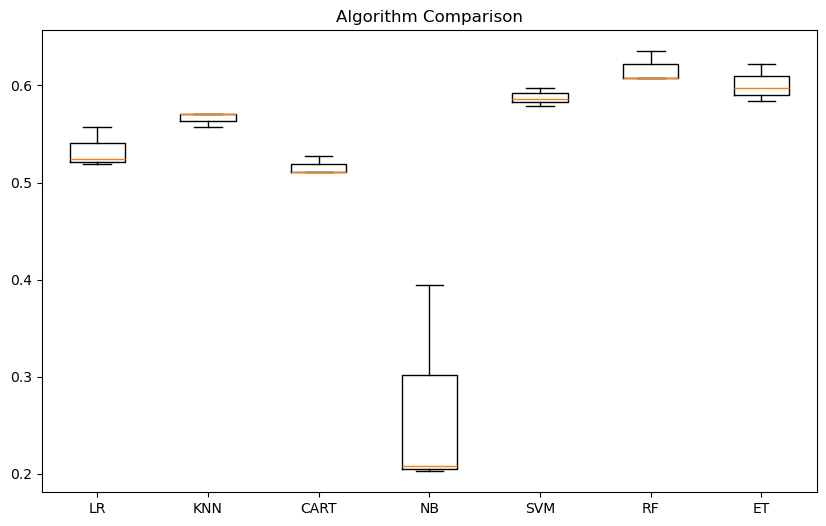

In [43]:
from matplotlib import pyplot

pyplot.figure(figsize=(10,6))
pyplot.boxplot(results)
pyplot.xticks(range(1, len(names)+1), names)
pyplot.title("Algorithm Comparison")
plt.savefig("figures/algorithm_comparison.png", dpi=300, bbox_inches="tight")
pyplot.show()

## Hyperparameter Optimization

After comparing multiple algorithms, Random Forest was selected as the best candidate model.

Before evaluating it on the benchmark fold, a small hyperparameter optimization step is performed using GridSearchCV.

The benchmark fold (`fold = -1`) is not used during tuning. Only folds `0`, `1`, and `2` are used.

In [32]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X, Y)

print("Best score:", round(grid.best_score_, 4))
print("Best parameters:", grid.best_params_)

Best score: 0.6207
Best parameters: {'max_depth': 15, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


GridSearchCV evaluates different combinations of Random Forest hyperparameters using cross-validation.

The best parameters are selected based only on the training folds.

This prevents data leakage and keeps the benchmark fold available for final evaluation.

In [33]:
best_rf_model = grid.best_estimator_

print(best_rf_model)

RandomForestClassifier(class_weight='balanced', max_depth=15,
                       max_features='log2', n_estimators=300, random_state=42)


The expanded grid search slightly improved the Random Forest performance, increasing the cross-validation accuracy from approximately 61.7% to 62.1%.

The best configuration uses:

- `n_estimators = 300`
- `max_depth = 15`
- `max_features = "log2"`


Although the improvement is small, hyperparameter tuning helps identify a more optimized and stable model configuration.

## Final Benchmark Evaluation

After model comparison and hyperparameter tuning, the optimized Random Forest model is selected as the final model.

The final model is trained on all training folds (`0`, `1`, and `2`) and evaluated only once on the benchmark fold (`-1`).

This benchmark fold was not used during feature selection, model comparison, or hyperparameter tuning, so it represents unseen data.

In [34]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, matthews_corrcoef

train_data = data[data["fold"] != -1]
benchmark_data = data[data["fold"] == -1]

X_train_final = train_data[feature_names].values
Y_train_raw = train_data["class"].values

X_benchmark = benchmark_data[feature_names].values
Y_benchmark_raw = benchmark_data["class"].values

le = LabelEncoder()
Y_train_final = le.fit_transform(Y_train_raw)
Y_benchmark = le.transform(Y_benchmark_raw)

# Use the best model from GridSearchCV !!
final_model = grid.best_estimator_

final_model.fit(X_train_final, Y_train_final)

# Predict benchmark
Y_benchmark_pred = final_model.predict(X_benchmark)

# Evaluation metrics
accuracy = accuracy_score(Y_benchmark, Y_benchmark_pred)
mcc = matthews_corrcoef(Y_benchmark, Y_benchmark_pred)

print("Final Benchmark Accuracy:", round(accuracy, 4))
print("Final Benchmark MCC:", round(mcc, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(Y_benchmark, Y_benchmark_pred))

print("\nClassification Report:")
print(classification_report(Y_benchmark, Y_benchmark_pred, target_names=le.classes_))

Final Benchmark Accuracy: 0.623
Final Benchmark MCC: 0.5148

Confusion Matrix:
[[81  0  0  0  2  0 12 21  0  0]
 [ 0  2  0  0  0  0  0  0  0  0]
 [ 0  0  5  2  1  0  0  1  0  0]
 [ 0  0  1 10  0  0  0  0  0  0]
 [ 0  0  0  1  8  1  2  1  0  0]
 [ 2  0  0  0  0 36  0  2  0  1]
 [17  0  1  0  1  2 35  5  0  0]
 [41  0  0  0  0  6  7 54  0  0]
 [ 1  0  0  1  0  0  1  0  2  0]
 [ 5  0  0  0  0  1  1  1  0  0]]

Classification Report:
              precision    recall  f1-score   support

         CYT       0.55      0.70      0.62       116
         ERL       1.00      1.00      1.00         2
         EXC       0.71      0.56      0.62         9
         ME1       0.71      0.91      0.80        11
         ME2       0.67      0.62      0.64        13
         ME3       0.78      0.88      0.83        41
         MIT       0.60      0.57      0.59        61
         NUC       0.64      0.50      0.56       108
         POX       1.00      0.40      0.57         5
         VAC       0.00  

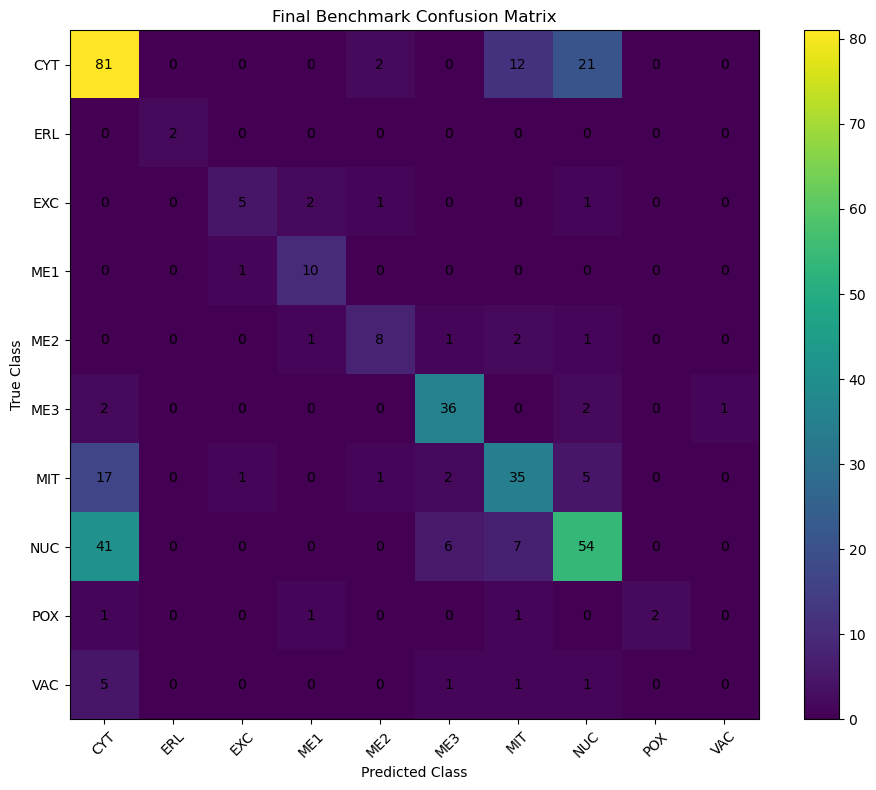

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

# Confusion matrix
cm = confusion_matrix(Y_benchmark, Y_benchmark_pred)

cm_df = pd.DataFrame(
    cm,
    index=le.classes_,
    columns=le.classes_
)

plt.figure(figsize=(10, 8))
plt.imshow(cm_df, interpolation="nearest")
plt.title("Final Benchmark Confusion Matrix")
plt.colorbar()

tick_marks = range(len(le.classes_))
plt.xticks(tick_marks, le.classes_, rotation=45)
plt.yticks(tick_marks, le.classes_)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

# Write values inside heatmap cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig("figures/final_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [45]:
precision_weighted = precision_score(Y_benchmark, Y_benchmark_pred, average="weighted", zero_division=0)
recall_weighted = recall_score(Y_benchmark, Y_benchmark_pred, average="weighted", zero_division=0)
f1_weighted = f1_score(Y_benchmark, Y_benchmark_pred, average="weighted", zero_division=0)

print("\nWeighted Precision:", round(precision_weighted, 4))
print("Weighted Recall:", round(recall_weighted, 4))
print("Weighted F1-score:", round(f1_weighted, 4))


Weighted Precision: 0.6187
Weighted Recall: 0.623
Weighted F1-score: 0.6131


Note: Matthews Correlation Coefficient (MCC)

- In addition to accuracy and classification metrics, the Matthews Correlation Coefficient (MCC) is also reported.

- MCC is useful for imbalanced classification problems because it considers all prediction outcomes together and provides a more balanced evaluation than accuracy alone.

The tuned Random Forest model achieved the best overall performance on the benchmark dataset.

Compared to the Logistic Regression baseline, the Random Forest model improved both overall accuracy and class-level performance.

Key observations:

- Final benchmark accuracy reached approximately 62.3%
- MCC increased to approximately 0.51, indicating moderate overall predictive quality
- Minority classes such as ERL, EXC, ME1, and POX were predicted much more successfully compared to the baseline model

The macro-average F1-score also improved substantially, showing that the model no longer focuses only on dominant classes.

These results confirm that the Yeast dataset contains complex non-linear relationships that are better captured by ensemble tree-based methods.

However, some minority classes such as VAC remain difficult to predict due to the very limited number of available samples.

Overall, the tuned Random Forest model provides the most balanced and reliable performance among the tested approaches.

## Save The Final Model

The final tuned Random Forest model and the label encoder are saved for future reuse.

This allows the trained model to be loaded later without retraining the entire pipeline.

In [38]:
import joblib

joblib.dump(final_model, "models/final_random_forest_model.pkl")
joblib.dump(le, "models/label_encoder.pkl")

['models/label_encoder.pkl']

# Conclusion

In this project, machine learning methods were applied to the Yeast Protein Localization dataset in order to predict the cellular localization site of yeast proteins using numerical biological features.

The project started with exploratory data analysis, where class imbalance, feature distributions, skewness, and feature correlations were investigated. The analysis showed that the dataset is highly imbalanced and that several features contain sparse biological signals associated with specific localization mechanisms.

Many of the features used in the dataset are biologically meaningful predictors of protein targeting. For example:

- `mcg` and `gvh` are related to signal sequence recognition methods,
- `alm` estimates membrane-spanning regions,
- `mit` captures mitochondrial targeting characteristics,
- `erl` represents the presence of the HDEL endoplasmic reticulum retention signal,
- `pox` reflects peroxisomal targeting signals,
- `nuc` measures nuclear localization signal patterns.

The strong skewness observed for features such as `erl` and `pox` appears biologically meaningful rather than noisy. These features correspond to highly specific targeting or retention signals that are expected to occur only in a limited subset of proteins. This explains why only a small number of proteins activate these signals strongly.

Feature selection techniques including Chi-Square selection, Recursive Feature Elimination (RFE), and tree-based feature importance methods were explored. Tree-based approaches were found to be more suitable for this dataset because they can better model non-linear relationships and are more robust to class imbalance.

Different resampling strategies and evaluation methods were then applied to estimate model performance reliably. Since the dataset includes predefined benchmark folds, all feature selection, model comparison, and hyperparameter tuning steps were performed only on the training folds to avoid data leakage.

Several machine learning algorithms were compared, including Logistic Regression, KNN, Decision Trees, Naive Bayes, SVM, Random Forest, and ExtraTrees. Among these approaches, ensemble tree-based methods achieved the best performance.

After hyperparameter optimization using GridSearchCV, the tuned Random Forest model was selected as the final model. The final benchmark evaluation achieved approximately:

- Accuracy ≈ 62%
- MCC ≈ 0.51
- Weighted Precision ≈ 0.6187
- Weighted Recall ≈ 0.623
- Weighted F1-score ≈ 0.6131

The final model significantly improved the prediction of minority classes compared to the baseline Logistic Regression model, confirming that the dataset benefits from non-linear ensemble methods rather than simple linear classifiers.

Interestingly, some minority classes such as POX could still be recognized reasonably well despite having very few samples, while VAC remained difficult to classify. This suggests that class separability and feature informativeness may be more important than sample size alone.

A possible biological explanation is that peroxisomal proteins (POX) may contain more distinctive targeting-related signals that separate them from other localization classes, while vacuolar proteins (VAC) may share broader similarities with cytosolic, membrane-associated, or nuclear proteins. As a result, VAC proteins overlap more strongly with other classes in feature space, making classification more difficult despite having more samples than POX.

The results also suggest that protein localization is governed by complex and partially overlapping biological mechanisms rather than by a single dominant feature. Therefore, flexible ensemble models such as Random Forest are more suitable for capturing these interactions compared to simpler linear models.

Despite the improvements obtained with Random Forest, some minority classes remained difficult to classify because of both severe class imbalance and biological overlap between localization mechanisms. This represents one of the main limitations of the dataset.

In conclusion, the results show that Random Forest provides the most balanced and reliable performance for this multi-class protein localization problem.